# ABC Vincent - configurable cases + random search

Goal:

1. Choose either a simulated population or the MU284 population.
2. Choose whether to run all combinations or only specified combinations.
3. For each case, choose one variable as `z` and one size variable to generate `pi`.
4. Run ABC and Random Search, both starting from Vincent/Ppi.
5. Compare both against Vincent/Ppi optimal efficiency.


## Meaning of the four final ratios

`ABC_z_over_Ppi_z`: ABC efficiency for `z` divided by Vincent/Ppi efficiency for `z`.

`ABC_y_over_Ppi_y`: ABC efficiency for `y` divided by Vincent/Ppi efficiency for `y`.

`Random_z_over_Ppi_z`: Random Search efficiency for `z` divided by Vincent/Ppi efficiency for `z`.

`Random_y_over_Ppi_y`: Random Search efficiency for `y` divided by Vincent/Ppi efficiency for `y`.

A value above `1.00` means better than Vincent/Ppi. A value near `1.00` means about equal.

In [142]:
from pathlib import Path
import contextlib
import importlib.util
import io

import numpy as np
import pandas as pd


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        runner_path = path / "simulations_abc" / "terminal_running" / "run_abc_mu284_terminal.py"
        if runner_path.exists():
            return path
    raise RuntimeError("Could not find project root.")


PROJECT_ROOT = find_project_root()
RUNNER_PATH = PROJECT_ROOT / "simulations_abc" / "terminal_running" / "run_abc_mu284_terminal.py"

spec = importlib.util.spec_from_file_location("vincent_runner", RUNNER_PATH)
runner = importlib.util.module_from_spec(spec)
with contextlib.redirect_stdout(io.StringIO()):
    spec.loader.exec_module(runner)

print("Loaded ABC code from:", RUNNER_PATH)

Loaded ABC code from: /home/bardia/projects/graphical-sampling/simulations_abc/terminal_running/run_abc_mu284_terminal.py


## Settings

Change only this block for most experiments.

`POPULATION_SOURCE` options:

- `"simulated"`: generate one synthetic population with independent `z_90`, `z_80`, `z_00` and `size_90`, `size_80`, `size_00` variables.
- `"MU284"`: use the real MU284 data.

`CASE_MODE` options:

- `"all"`: run all `z x size` combinations.
- `"specified"`: run only the pairs listed in `SPECIFIED_CASES`.


In [143]:
# Choose data source: "simulated" or "MU284"
POPULATION_SOURCE = "simulated"

# Choose cases: "all" or "specified"
CASE_MODE = "all"

# Used only when CASE_MODE = "specified".
# Each tuple is: (z_variable, size_variable).
# The size_variable is used to generate the final inclusion probabilities pi.
# For simulated data use names like ("z_90", "size_80").
# For MU284 use names like ("ME84", "S82").
SPECIFIED_CASES = [
    ("z_90", "size_90"),
    ("z_90", "size_80"),
    ("z_80", "size_90"),
]

# Simulated-population settings
N_UNITS = 50
SIMULATED_CORRELATIONS = [0.90, 0.80, 0.00]

# Controls how strongly the size variable affects pi.
# Larger values make pi more unequal; smaller values reduce extreme y/pi values.
PI_SIZE_STRENGTH = 0.35

# MU284 settings
MU284_PATH = PROJECT_ROOT / "simulations_abc" / "populations" / "real" / "MU284.csv"
MU284_Y_VAR = "P85"
MU284_AUXILIARIES = ["ME84", "S82", "SS82", "REG", "P75"]

# Shared sampling/search settings
N_SAMPLE = 5

# PI_MODE options:
# "auxiliary": build pi from the selected size_variable.
# "equal": use equal-probability sampling, so corr(y/pi,z/pi)=corr(y,z).
# "mix": blend equal size and auxiliary size; PI_MIX_ALPHA=0 is almost equal, 1 is auxiliary.
PI_MODE = "auxiliary"
PI_MIX_ALPHA = 1.0

COLONY_SIZE = 20
MAX_ITERATIONS = 50
PROGRESS_INTERVAL = 10  # print every m iterations
LIMIT = 5
ONLOOKER_FACTOR = 0.5

RANDOM_START_EVALS = COLONY_SIZE
RANDOM_EVALS_PER_ITERATION = int(round(COLONY_SIZE * (1.0 + ONLOOKER_FACTOR)))

# Objective options: "eff_z", "eff_y", "mean", "harmonic",
# "mean_relative", "harmonic_relative", "min_relative".
OBJECTIVE = "min_relative"

INITIAL_OMEGA_VALUE = 0.0
INITIAL_RHO_VALUE = 0.5
BASE_SEED = 202600384


## MU284 correlation helper

Run this cell when `POPULATION_SOURCE = "MU284"` or when you want to choose MU284 variables.

It prints all numeric-variable correlations rounded to 2 decimals. Use this table to choose:

- `MU284_Y_VAR` as the main variable
- `MU284_AUXILIARIES` as candidate `z` and size variables


In [144]:
mu284_raw = pd.read_csv(MU284_PATH)
mu284_numeric = mu284_raw.select_dtypes(include=[np.number])
mu284_corr = mu284_numeric.corr().round(2)

print("Numeric MU284 variables:")
print(list(mu284_numeric.columns))

mu284_corr


Numeric MU284 variables:
['LABEL', 'P85', 'P75', 'RMT85', 'CS82', 'SS82', 'S82', 'ME84', 'REV84', 'REG', 'CL']


,LABEL,P85,P75,RMT85,CS82,SS82,S82,ME84,REV84,REG,CL
LABEL,1.00,-0.18,-0.15,-0.17,-0.56,0.11,-0.17,-0.17,-0.15,0.83,1.00
P85,-0.18,1.00,1.00,0.99,0.67,0.65,0.87,0.99,0.91,-0.19,-0.18
P75,-0.15,1.00,1.00,0.99,0.64,0.68,0.87,0.99,0.90,-0.17,-0.15
RMT85,-0.17,0.99,0.99,1.00,0.66,0.65,0.85,0.99,0.91,-0.19,-0.16
CS82,-0.56,0.67,0.64,0.66,1.00,0.15,0.62,0.65,0.61,-0.45,-0.56
SS82,0.11,0.65,0.68,0.65,0.15,1.00,0.75,0.66,0.60,0.02,0.12
S82,-0.17,0.87,0.87,0.85,0.62,0.75,1.00,0.85,0.80,-0.15,-0.17
ME84,-0.17,0.99,0.99,0.99,0.65,0.66,0.85,1.00,0.91,-0.19,-0.16
REV84,-0.15,0.91,0.90,0.91,0.61,0.60,0.80,0.91,1.00,-0.14,-0.15
REG,0.83,-0.19,-0.17,-0.19,-0.45,0.02,-0.15,-0.19,-0.14,1.00,0.83


## Prepare the population

This cell creates a common object called `df_pop`.

`df_pop` always contains one column called `y`.

For simulated data, it also contains two independent families:

- `z_90`, `z_80`, `z_00` for the optimization variable `z`
- `size_90`, `size_80` for unequal inclusion probabilities, and `size_00` for equal probabilities

`size_00` means `pi = n / N` for every unit.


In [145]:
def standardize(x):
    x = np.asarray(x, dtype=float)
    sd = x.std(ddof=1)
    if sd == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / sd


def make_size_for_pi(x):
    # Bounded positive size: avoids tiny pi values that create huge y/pi outliers.
    return np.exp(PI_SIZE_STRENGTH * standardize(x))


def build_pi_from_size_variable(size_values, size_name=None):
    pi_mode = str(PI_MODE).strip().lower()
    if pi_mode == "equal" or size_name == "size_00":
        return np.full(len(size_values), N_SAMPLE / len(size_values))

    size_aux = make_size_for_pi(size_values)
    if pi_mode == "auxiliary":
        size = size_aux
    elif pi_mode == "mix":
        alpha = float(PI_MIX_ALPHA)
        size = (1.0 - alpha) * np.mean(size_aux) + alpha * size_aux
    else:
        raise ValueError("PI_MODE must be auxiliary, equal, or mix")

    return runner.inclusionprobabilities(size, N_SAMPLE)


def corr_suffix(corr):
    return f"{int(round(corr * 100)):02d}"


def correlated_with_y(y_std, corr, rng):
    noise = rng.normal(size=len(y_std))
    noise = noise - np.mean(noise)
    noise = noise - np.dot(noise, y_std) / np.dot(y_std, y_std) * y_std
    noise = standardize(noise)
    return corr * y_std + np.sqrt(max(0.0, 1.0 - corr**2)) * noise


def make_simulated_population(n_units=N_UNITS, correlations=SIMULATED_CORRELATIONS, seed=BASE_SEED):
    rng = np.random.default_rng(seed)
    location = rng.uniform(80.0, 120.0)
    scale = rng.uniform(8.0, 18.0)
    y = location + scale * rng.normal(size=n_units)
    y_std = standardize(y)

    data = {"unit": np.arange(n_units), "y": y}
    z_names = []
    size_names = []

    for corr in correlations:
        suffix = corr_suffix(corr)

        z_name = f"z_{suffix}"
        size_name = f"size_{suffix}"

        data[z_name] = correlated_with_y(y_std, corr, rng)
        data[size_name] = correlated_with_y(y_std, corr, rng)

        z_names.append(z_name)
        size_names.append(size_name)

    return pd.DataFrame(data), z_names, size_names


def make_mu284_population():
    raw = pd.read_csv(MU284_PATH)
    needed = [MU284_Y_VAR, *MU284_AUXILIARIES]
    missing = [col for col in needed if col not in raw.columns]
    if missing:
        raise ValueError(f"Missing MU284 columns: {missing}")

    df = pd.DataFrame({"unit": np.arange(len(raw)), "y": raw[MU284_Y_VAR].to_numpy(dtype=float)})
    for col in MU284_AUXILIARIES:
        df[col] = raw[col].to_numpy(dtype=float)
    return df, list(MU284_AUXILIARIES), list(MU284_AUXILIARIES)


if POPULATION_SOURCE == "simulated":
    df_pop, z_names, size_names = make_simulated_population()
elif POPULATION_SOURCE == "MU284":
    df_pop, z_names, size_names = make_mu284_population()
else:
    raise ValueError("POPULATION_SOURCE must be either simulated or MU284")

aux_names = list(dict.fromkeys([*z_names, *size_names]))

z_corr_table = pd.Series(
    {name: np.corrcoef(df_pop["y"], df_pop[name])[0, 1] for name in z_names},
    name="corr_with_y",
)
size_corr_table = pd.Series(
    {name: np.corrcoef(df_pop["y"], df_pop[name])[0, 1] for name in size_names},
    name="corr_with_y",
)

print("population source:", POPULATION_SOURCE)
print("number of units:", len(df_pop))
print("z variables:", z_names)
print("size variables for pi:", size_names)

pd.concat({"z variables": z_corr_table, "size variables for pi": size_corr_table}).round(3)


population source: simulated
number of units: 50
z variables: ['z_90', 'z_80', 'z_00']
size variables for pi: ['size_90', 'size_80', 'size_00']


z variables            z_90       0.9
                       z_80       0.8
                       z_00      -0.0
size variables for pi  size_90    0.9
                       size_80    0.8
                       size_00    0.0
Name: corr_with_y, dtype: float64

## Simulated scatter plots

For the simulated population, this separates two questions.

Columns: low, medium, and high correlation between `y` and `z`.

Rows: raw `y` versus `z`, then `y / pi` versus `z / pi` using independent low, medium, and high correlation size variables to generate `pi`.


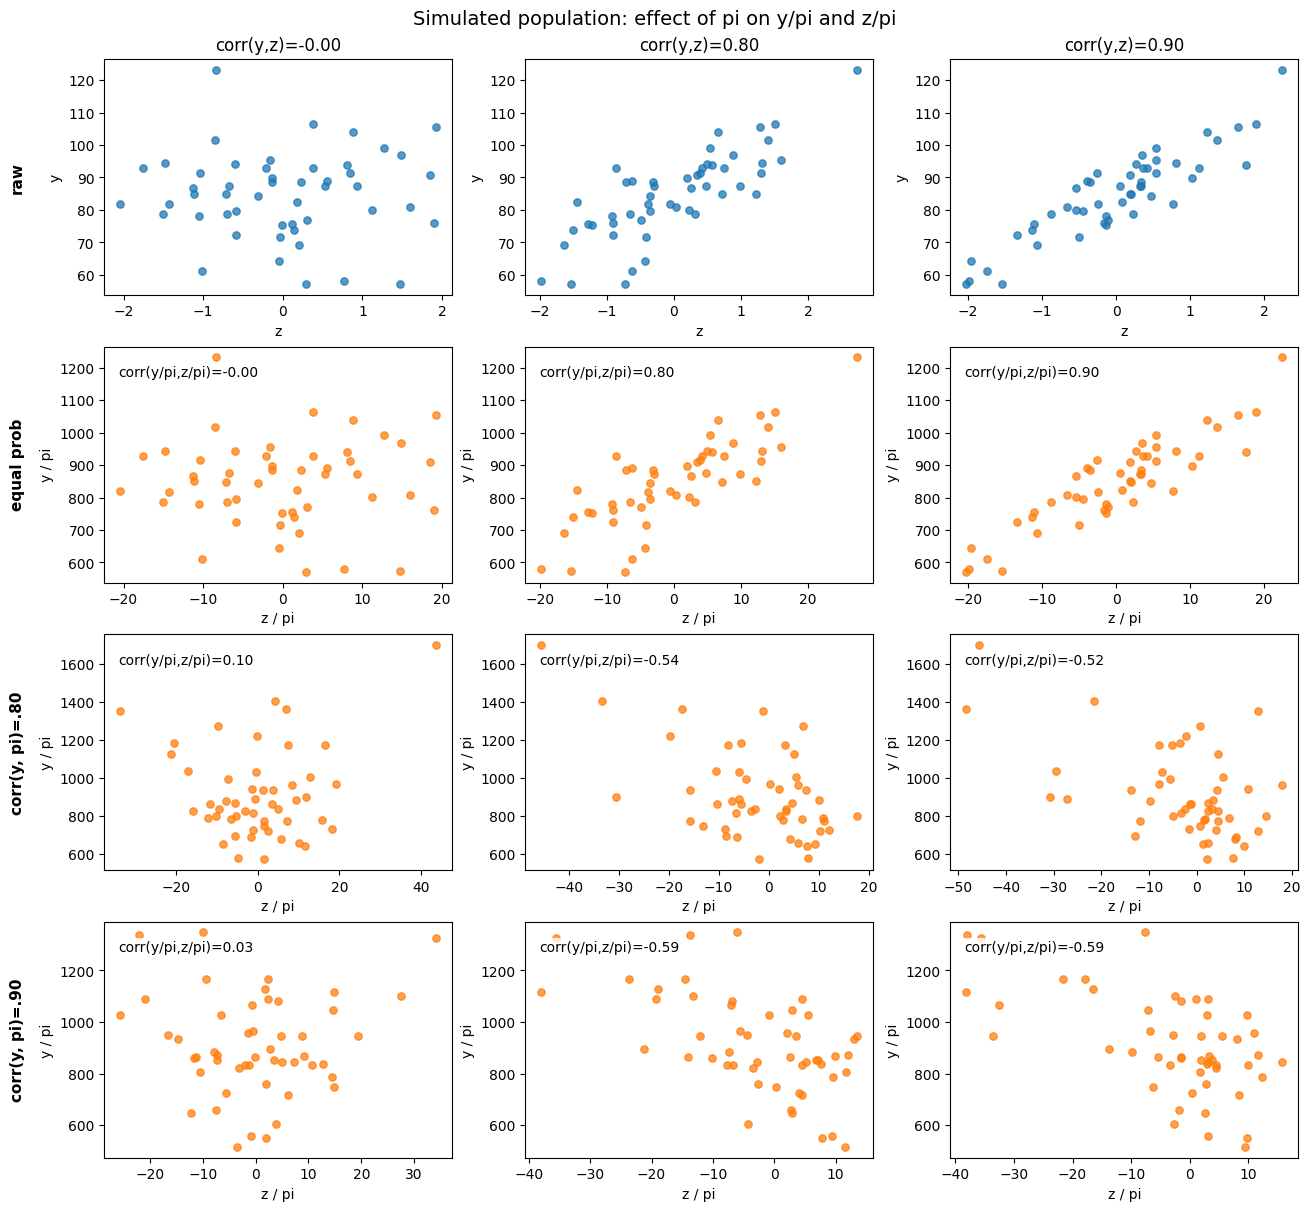

In [146]:
import matplotlib.pyplot as plt


def pi_for_plot(size_name):
    return build_pi_from_size_variable(df_pop[size_name].to_numpy(dtype=float), size_name=size_name)


def corr_with_y(name):
    y = df_pop["y"].to_numpy(dtype=float)
    x = df_pop[name].to_numpy(dtype=float)
    return np.corrcoef(y, x)[0, 1]


def name_for_target_corr(names, target):
    return min(names, key=lambda name: abs(abs(corr_with_y(name)) - target))


if POPULATION_SOURCE != "simulated":
    print("Set POPULATION_SOURCE = 'simulated' and rerun the population cell to draw these plots.")
else:
    y = df_pop["y"].to_numpy(dtype=float)

    plot_z_names = [
        name_for_target_corr(z_names, 0.00),
        name_for_target_corr(z_names, 0.80),
        name_for_target_corr(z_names, 0.90),
    ]
    plot_size_names = [
        "size_00",
        name_for_target_corr(size_names, 0.80),
        name_for_target_corr(size_names, 0.90),
    ]
    row_labels = [
        "raw",
        "equal prob",
        "corr(y, pi)=.80",
        "corr(y, pi)=.90",
    ]

    fig, axes = plt.subplots(4, 3, figsize=(13, 12), constrained_layout=True)

    for col, z_name in enumerate(plot_z_names):
        z = df_pop[z_name].to_numpy(dtype=float)
        corr_y_z = np.corrcoef(y, z)[0, 1]

        axes[0, col].scatter(z, y, s=28, alpha=0.75)
        axes[0, col].set_title(f"corr(y,z)={corr_y_z:.2f}")
        axes[0, col].set_xlabel("z")
        axes[0, col].set_ylabel("y")

        for row, size_name in enumerate(plot_size_names, start=1):
            pi = pi_for_plot(size_name)
            y_over_pi = y / pi
            z_over_pi = z / pi
            corr_ratio = np.corrcoef(y_over_pi, z_over_pi)[0, 1]

            axes[row, col].scatter(z_over_pi, y_over_pi, s=28, alpha=0.75, color="tab:orange")
            axes[row, col].text(
                0.04, 0.92, f"corr(y/pi,z/pi)={corr_ratio:.2f}",
                transform=axes[row, col].transAxes,
                ha="left", va="top", fontsize=10,
                bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none", "pad": 2},
            )
            axes[row, col].set_xlabel("z / pi")
            axes[row, col].set_ylabel("y / pi")

    for row, label in enumerate(row_labels):
        axes[row, 0].annotate(
            label,
            xy=(-0.25, 0.5),
            xycoords="axes fraction",
            rotation=90,
            va="center",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    fig.suptitle("Simulated population: effect of pi on y/pi and z/pi", fontsize=14)
    plt.show()


## Pi correlation diagnostics

This is the debugging check for the role of `pi`.

The important correlation for the variance is not only `corr(y, z)`.

It is also:

`corr(y / pi, z / pi)`

If `pi` is equal for all units, these two correlations are the same.

If `pi` is unequal, dividing by `pi` can change the geometry a lot.


In [147]:
def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


def residual_after_linear_effect(x, control):
    x = np.asarray(x, dtype=float)
    control = np.asarray(control, dtype=float)
    X = np.column_stack([np.ones(len(control)), control])
    beta = np.linalg.lstsq(X, x, rcond=None)[0]
    return x - X @ beta


def pi_correlation_diagnostics(df_pop, z_names, size_names):
    y = df_pop["y"].to_numpy(dtype=float)
    n_units = len(df_pop)
    pi_equal = np.full(n_units, N_SAMPLE / n_units)
    rows = []

    for z_var in z_names:
        z = df_pop[z_var].to_numpy(dtype=float)
        for size_var in size_names:
            size_source = df_pop[size_var].to_numpy(dtype=float)
            pi = build_pi_from_size_variable(size_source, size_name=size_var)
            inv_pi = 1.0 / pi
            y_over_pi = y / pi
            z_over_pi = z / pi
            y_resid = residual_after_linear_effect(y_over_pi, inv_pi)
            z_resid = residual_after_linear_effect(z_over_pi, inv_pi)
            rows.append({
                "z_variable": z_var,
                "size_variable": size_var,
                "same_variable": z_var == size_var,
                "corr_y_z": safe_corr(y, z),
                "corr_y_size": safe_corr(y, size_source),
                "corr_y_over_equal_pi_z_over_equal_pi": safe_corr(y / pi_equal, z / pi_equal),
                "corr_y_over_pi_z_over_pi": safe_corr(y_over_pi, z_over_pi),
                "partial_corr_after_1_over_pi": safe_corr(y_resid, z_resid),
                "corr_y_over_pi_with_1_over_pi": safe_corr(y_over_pi, inv_pi),
                "corr_z_over_pi_with_1_over_pi": safe_corr(z_over_pi, inv_pi),
                "corr_y_pi": safe_corr(y, pi),
                "corr_z_pi": safe_corr(z, pi),
                "pi_cv": np.std(pi) / np.mean(pi),
                "pi_min": np.min(pi),
                "pi_max": np.max(pi),
            })

    return pd.DataFrame(rows)


pi_diag = pi_correlation_diagnostics(df_pop, z_names, size_names)
pi_diag.sort_values(["corr_y_z", "corr_y_size"], ascending=False).round(3)


,z_variable,size_variable,same_variable,corr_y_z,corr_y_size,corr_y_over_equal_pi_z_over_equal_pi,corr_y_over_pi_z_over_pi,partial_corr_after_1_over_pi,corr_y_over_pi_with_1_over_pi,corr_z_over_pi_with_1_over_pi,corr_y_pi,corr_z_pi,pi_cv,pi_min,pi_max
0,z_90,size_90,False,0.9,0.9,0.9,-0.588,0.766,0.919,-0.825,0.866,0.731,0.366,0.043,0.239
1,z_90,size_80,False,0.9,0.8,0.9,-0.517,0.810,0.916,-0.784,0.797,0.717,0.322,0.034,0.177
2,z_90,size_00,False,0.9,0.0,0.9,0.900,0.900,NaN,NaN,0.000,-0.000,0.000,0.100,0.100
3,z_80,size_90,False,0.8,0.9,0.8,-0.586,0.424,0.919,-0.756,0.866,0.726,0.366,0.043,0.239
4,z_80,size_80,False,0.8,0.8,0.8,-0.543,0.539,0.916,-0.749,0.797,0.641,0.322,0.034,0.177
5,z_80,size_00,False,0.8,0.0,0.8,0.800,0.800,NaN,NaN,0.000,-0.000,0.000,0.100,0.100
6,z_00,size_90,False,-0.0,0.9,-0.0,0.033,-0.137,0.919,0.094,0.866,-0.034,0.366,0.043,0.239
7,z_00,size_80,False,-0.0,0.8,-0.0,0.103,-0.237,0.916,0.214,0.797,0.081,0.322,0.034,0.177
8,z_00,size_00,False,-0.0,0.0,-0.0,-0.000,-0.000,NaN,NaN,0.000,0.000,0.000,0.100,0.100


## One function to run one case

One case means:

- choose one auxiliary variable for `z`
- choose one size variable to generate `pi`
- run ABC and Random Search
- compare both with Vincent/Ppi


In [148]:
def ratio(value, reference):
    return value / reference if reference > 0 and value > 0 else np.nan


def run_case(df_pop, z_var, size_var, case_seed):
    y_raw = df_pop["y"].to_numpy(dtype=float)
    z_raw = df_pop[z_var].to_numpy(dtype=float)

    # Build final inclusion probabilities pi. Equal pi preserves corr(y,z) on the ratio scale.
    pi_raw = build_pi_from_size_variable(df_pop[size_var].to_numpy(dtype=float), size_name=size_var)

    sort_idx = np.argsort(z_raw / pi_raw)
    y_sorted = y_raw[sort_idx]
    z_sorted = z_raw[sort_idx]
    pi_sorted = pi_raw[sort_idx]

    N = len(df_pop)
    var_srs_y = N**2 * (1.0 - N_SAMPLE / N) * np.var(y_raw, ddof=1) / N_SAMPLE
    var_srs_z = N**2 * (1.0 - N_SAMPLE / N) * np.var(z_raw, ddof=1) / N_SAMPLE

    abc = runner.ABCAlgorithm(
        y_sorted=y_sorted,
        z_sorted=z_sorted,
        pik_sorted=pi_sorted,
        var_srs_y=var_srs_y,
        var_srs_z=var_srs_z,
        M=N_SAMPLE,
        n=N_SAMPLE,
        case_name=f"z_{z_var}_pi_from_{size_var}",
        objective=OBJECTIVE,
        enforce_cadsd_order=True,
        random_state=case_seed,
        validation_mode="fast",
        initial_omega_value=INITIAL_OMEGA_VALUE,
        initial_rho_value=INITIAL_RHO_VALUE,
    )

    random_search = runner.RandomSearchAlgorithm(
        y_sorted=y_sorted,
        z_sorted=z_sorted,
        pik_sorted=pi_sorted,
        var_srs_y=var_srs_y,
        var_srs_z=var_srs_z,
        M=N_SAMPLE,
        n=N_SAMPLE,
        case_name=f"z_{z_var}_pi_from_{size_var}_random",
        objective=OBJECTIVE,
        enforce_cadsd_order=True,
        random_state=case_seed + 500_000,
        validation_mode="fast",
        initial_omega_value=INITIAL_OMEGA_VALUE,
        initial_rho_value=INITIAL_RHO_VALUE,
    )

    result = abc.optimize(
        colony_size=COLONY_SIZE,
        max_iterations=MAX_ITERATIONS,
        limit=LIMIT,
        verbose=True,
        progress_interval=PROGRESS_INTERVAL,
        local_search_interval=4,
        local_search_attempts=1,
        onlooker_factor=ONLOOKER_FACTOR,
        early_stopping=False,
        min_iterations=1,
        random_searcher=random_search,
        random_start_evals=RANDOM_START_EVALS,
        random_evals_per_iteration=RANDOM_EVALS_PER_ITERATION,
    )

    return {
        "z_variable": z_var,
        "size_variable": size_var,
        "pi_mode": PI_MODE,
        "pi_mix_alpha": PI_MIX_ALPHA if str(PI_MODE).strip().lower() == "mix" else np.nan,
        "pi_size_strength": PI_SIZE_STRENGTH,
        "corr_y_z": np.corrcoef(y_raw, z_raw)[0, 1],
        "corr_y_size": np.corrcoef(y_raw, df_pop[size_var].to_numpy(dtype=float))[0, 1],
        "Ppi_z_eff": result["optimal_eff_z"],
        "Ppi_y_eff": result["optimal_eff_y"],
        "ABC_z_eff": result["best_eff_z"],
        "ABC_y_eff": result["best_eff_y"],
        "Random_z_eff": result["random_best_eff_z"],
        "Random_y_eff": result["random_best_eff_y"],
        "ABC_z_over_Ppi_z": ratio(result["best_eff_z"], result["optimal_eff_z"]),
        "ABC_y_over_Ppi_y": ratio(result["best_eff_y"], result["optimal_eff_y"]),
        "Random_z_over_Ppi_z": ratio(result["random_best_eff_z"], result["optimal_eff_z"]),
        "Random_y_over_Ppi_y": ratio(result["random_best_eff_y"], result["optimal_eff_y"]),
        "ABC_valid_percent": result["abc_valid_percent"],
        "Random_valid_percent": result["random_valid_percent"],
        "evaluations_ABC": result["eval_count"],
        "evaluations_Random": result["random_eval_count"],
    }


## Iteration output to watch

During each case, the optimizer prints one row per iteration.

The most important columns are:

- `ABC_z/Ppi_z`: ABC efficiency relative to Vincent/Ppi for `z`.
- `ABC_y/Ppi_y`: ABC efficiency relative to Vincent/Ppi for `y`.

`1.00` means equal to Vincent/Ppi. Above `1.00` means ABC improved on Vincent/Ppi.


## Run selected cases

If `CASE_MODE = "all"`, this runs every `z x size` pair.

If `CASE_MODE = "specified"`, this runs only `SPECIFIED_CASES`.


In [149]:
def build_cases():
    case_mode = str(CASE_MODE).strip().lower()
    if case_mode == "all":
        return [(z_var, size_var) for z_var in z_names for size_var in size_names]
    if case_mode == "specified":
        bad = [pair for pair in SPECIFIED_CASES if pair[0] not in z_names or pair[1] not in size_names]
        if bad:
            raise ValueError(
                f"SPECIFIED_CASES contains unknown variable pairs: {bad}. "
                f"Available z variables: {z_names}. Available size variables: {size_names}."
            )
        return list(SPECIFIED_CASES)
    raise ValueError(f"CASE_MODE must be 'all' or 'specified', got {CASE_MODE!r}")


case_pairs = build_cases()
seed_names = list(dict.fromkeys([*z_names, *size_names]))
aux_seed_shift = {name: i + 1 for i, name in enumerate(seed_names)}

records = []
for z_var, size_var in case_pairs:
    print(f"Running z={z_var}, pi from size={size_var}...")
    seed = BASE_SEED + 1000 * aux_seed_shift[z_var] + aux_seed_shift[size_var]
    records.append(run_case(df_pop, z_var, size_var, seed))

results = pd.DataFrame(records)
print("number of cases:", len(results))
results.round(4)


Running z=z_90, pi from size=size_90...
 ABC ALGORITHM - z_z_90_pi_from_size_90
 Configuration:
   colony_size          = 20
   max_iterations       = 50
   abandonment limit    = 5
   objective            = min_relative
   warm start           = omega=0, rho=0.5
   validation mode      = fast
   onlooker factor      = 0.5
   early stopping       = False, patience=25
   time limit           = None
   random search        = ON
   random start evals   = 20
   random evals/iter    = 30
   progress interval    = every 10 iterations
   local search interval= every 4 iterations
 Reference Pπ efficiency versus SRS:
   Pπ_z = 1.42
   Pπ_y = 2.68

 Initializing 20 food sources...

    Initialized 20 food sources (requested 20)
    Warm start: omega=0, rho=0.5
    Best initial: eff_z=1.4203, eff_y=2.6848
 iter | ABC_z/Pπ_z | ABC_y/Pπ_y | Rand_z/Pπ_z | Rand_y/Pπ_y | scout | ABC val% | Rnd val% |  elapsed
---------------------------------------------------------------------------------------------

,z_variable,size_variable,pi_mode,pi_mix_alpha,pi_size_strength,corr_y_z,corr_y_size,Ppi_z_eff,Ppi_y_eff,ABC_z_eff,...,Random_z_eff,Random_y_eff,ABC_z_over_Ppi_z,ABC_y_over_Ppi_y,Random_z_over_Ppi_z,Random_y_over_Ppi_y,ABC_valid_percent,Random_valid_percent,evaluations_ABC,evaluations_Random
0,z_90,size_90,auxiliary,NaN,0.35,0.9,0.9,1.4203,2.6847,1.4203,...,1.4203,2.6848,1.0000,1.0000,1.0,1.0000,99.9287,100.0000,4207,1520
1,z_90,size_80,auxiliary,NaN,0.35,0.9,0.8,1.2476,1.4410,1.2667,...,1.2476,1.4410,1.0153,1.0161,1.0,1.0000,99.9776,100.0000,4457,1520
2,z_90,size_00,auxiliary,NaN,0.35,0.9,0.0,10.4261,2.9394,10.4263,...,10.4263,2.9402,1.0000,1.0003,1.0,1.0003,99.9713,99.9342,3482,1520
3,z_80,size_90,auxiliary,NaN,0.35,0.8,0.9,1.5027,2.6847,1.5027,...,1.5027,2.6848,1.0000,1.0000,1.0,1.0000,99.9530,99.9342,4257,1520
4,z_80,size_80,auxiliary,NaN,0.35,0.8,0.8,1.2536,1.4410,1.3808,...,1.2536,1.4410,1.1015,1.0987,1.0,1.0000,99.9485,100.0000,3882,1520
5,z_80,size_00,auxiliary,NaN,0.35,0.8,0.0,9.8681,2.2438,9.8683,...,9.8683,2.2443,1.0000,1.0002,1.0,1.0002,99.9713,99.9342,3482,1520
6,z_00,size_90,auxiliary,NaN,0.35,-0.0,0.9,0.8761,2.6847,0.8763,...,0.8761,2.6848,1.0002,1.0013,1.0,1.0000,100.0000,99.8026,4182,1520
7,z_00,size_80,auxiliary,NaN,0.35,-0.0,0.8,0.8311,1.4410,0.8885,...,0.8311,1.4410,1.0690,1.0689,1.0,1.0000,100.0000,99.8684,3532,1520
8,z_00,size_00,auxiliary,NaN,0.35,-0.0,0.0,12.9403,1.0089,12.9406,...,12.9406,1.0090,1.0000,1.0001,1.0,1.0001,99.9145,99.9342,3508,1520


## Compact final table

This is the main table to read.

In [150]:
main_cols = [
    "z_variable", "size_variable", "pi_mode", "pi_mix_alpha", "pi_size_strength",
    "corr_y_z", "corr_y_size",
    "ABC_z_over_Ppi_z", "ABC_y_over_Ppi_y",
    "Random_z_over_Ppi_z", "Random_y_over_Ppi_y",
]

results[main_cols].round(3)


,z_variable,size_variable,pi_mode,pi_mix_alpha,pi_size_strength,corr_y_z,corr_y_size,ABC_z_over_Ppi_z,ABC_y_over_Ppi_y,Random_z_over_Ppi_z,Random_y_over_Ppi_y
0,z_90,size_90,auxiliary,NaN,0.35,0.9,0.9,1.000,1.000,1.0,1.0
1,z_90,size_80,auxiliary,NaN,0.35,0.9,0.8,1.015,1.016,1.0,1.0
2,z_90,size_00,auxiliary,NaN,0.35,0.9,0.0,1.000,1.000,1.0,1.0
3,z_80,size_90,auxiliary,NaN,0.35,0.8,0.9,1.000,1.000,1.0,1.0
4,z_80,size_80,auxiliary,NaN,0.35,0.8,0.8,1.102,1.099,1.0,1.0
5,z_80,size_00,auxiliary,NaN,0.35,0.8,0.0,1.000,1.000,1.0,1.0
6,z_00,size_90,auxiliary,NaN,0.35,-0.0,0.9,1.000,1.001,1.0,1.0
7,z_00,size_80,auxiliary,NaN,0.35,-0.0,0.8,1.069,1.069,1.0,1.0
8,z_00,size_00,auxiliary,NaN,0.35,-0.0,0.0,1.000,1.000,1.0,1.0


## Average by z variable

This gives the broad pattern across the 3 inclusion-probability choices.


In [151]:
summary_by_z = (
    results
    .groupby("z_variable")[[
        "corr_y_z",
        "ABC_z_over_Ppi_z", "ABC_y_over_Ppi_y",
        "Random_z_over_Ppi_z", "Random_y_over_Ppi_y",
    ]]
    .mean()
    .round(3)
)

summary_by_z


,corr_y_z,ABC_z_over_Ppi_z,ABC_y_over_Ppi_y,Random_z_over_Ppi_z,Random_y_over_Ppi_y
z_variable,,,,,
z_00,-0.0,1.023,1.023,1.0,1.0
z_80,0.8,1.034,1.033,1.0,1.0
z_90,0.9,1.005,1.005,1.0,1.0


## Save results

The CSV is stored in `artifacts/` so the notebook folder stays clean.


In [ ]:
OUT_DIR = PROJECT_ROOT / "simulations_abc" / "jupyters" / "artifacts"
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / f"abc_random_{POPULATION_SOURCE}_{CASE_MODE}_cases.csv"
results.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)


Saved: /home/bardia/projects/graphical-sampling/simulations_abc/jupyters/artifacts/abc_random_simulated_all_cases.csv


: 